# News Dataset EDA

In this Notebook we carry out an exploratory data analysis of the news dataset, which is available at https://github.com/Zdong104/FNSPID_Financial_News_Dataset

We also achieve a cleaned and filtered version of the dataset, which is used in the event detection task.

In [2]:
# from datasets import load_dataset
import pandas as pd
from itertools import islice
import numpy as np

import pyarrow as pa
import os
import time
# import pyarrow.parquet as pq

import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter,defaultdict

## Utils to load dataset by chunks

In [ ]:
# ! wget https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_price/full_history.zip
# ! wget https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
def stream_to_pandas_chunks(stream, chunk_size=100_000):
    it = iter(stream)
    while True:
        chunk = list(islice(it, chunk_size))
        if not chunk:
            break
        yield pd.DataFrame(chunk)


dataset_stream = load_dataset("Zihan1004/FNSPID", streaming=True)
train_stream = dataset_stream["train"]

CHUNK_SIZE = 100_000

time_init = time.time()

try:
    for i, df_chunk in enumerate(stream_to_pandas_chunks(train_stream,CHUNK_SIZE)):
        print(f"Chunk {i+1}: {df_chunk.shape}")
        # eda and stats here
except KeyboardInterrupt:
    print("Streaming interrupted by user.")
finally:
    time_end = time.time()
    print(f"Total time for {i} chunks: {time_end - time_init:.2f} s")

Repo card metadata block was not found. Setting CardData to empty.


Chunk 1: (100000, 11)
Chunk 2: (100000, 11)
Chunk 3: (100000, 11)
Chunk 4: (100000, 11)
Chunk 5: (100000, 11)
Chunk 6: (100000, 11)
Streaming interrupted by user.
Total time for 5 chunks: 16.75


In [ ]:
# a more efficient way (?)

os.makedirs("chunks", exist_ok=True)

def convert_batch_to_df(batch):
    table = pa.Table.from_pylist(batch)
    return table.to_pandas()

def stream_to_pandas_chunks(stream, chunk_size=100_000):
    it = iter(stream)
    while True:
        chunk = list(islice(it, chunk_size))
        if not chunk:
            break
        yield convert_batch_to_df(chunk)

dataset_stream = load_dataset("Zihan1004/FNSPID", streaming=True)
train_stream = dataset_stream["train"]
CHUNK_SIZE = 100_000
time_init = time.time()

try:
    for i, df_chunk in enumerate(stream_to_pandas_chunks(train_stream, chunk_size=CHUNK_SIZE), start=1):
        print(f"Chunk {i}: {df_chunk.shape}")
        df_chunk.to_feather(f"chunks/chunk_{i}.feather")  # Offload to disk
        del df_chunk  # Free memory
except KeyboardInterrupt:
    print("Streaming interrupted by user.")
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    time_end = time.time()
    print(f"Total time for {i} chunks (size-{CHUNK_SIZE}): {time_end - time_init:.2f} s")
    print(f"total rows processed: {i * CHUNK_SIZE}")

Repo card metadata block was not found. Setting CardData to empty.


Chunk 1: (100000, 11)
Chunk 2: (100000, 11)
Chunk 3: (100000, 11)
Chunk 4: (100000, 11)
Chunk 5: (100000, 11)
Chunk 6: (100000, 11)
Chunk 7: (100000, 11)
Chunk 8: (100000, 11)
Chunk 9: (100000, 11)
Chunk 10: (100000, 11)
Chunk 11: (100000, 11)
Chunk 12: (100000, 11)
Chunk 13: (100000, 11)
Chunk 14: (100000, 11)
Chunk 15: (100000, 11)
Chunk 16: (100000, 11)
Chunk 17: (100000, 11)
Chunk 18: (100000, 11)
Chunk 19: (100000, 11)
Chunk 20: (100000, 11)
Chunk 21: (100000, 11)
Chunk 22: (100000, 11)
Chunk 23: (100000, 11)
Chunk 24: (100000, 11)
Chunk 25: (100000, 11)
Chunk 26: (100000, 11)
Chunk 27: (100000, 11)
Chunk 28: (100000, 11)
Chunk 29: (100000, 11)
Chunk 30: (100000, 11)
Chunk 31: (100000, 11)
Chunk 32: (100000, 11)
Chunk 33: (100000, 11)
Chunk 34: (100000, 11)
Chunk 35: (100000, 11)
Chunk 36: (100000, 11)
Chunk 37: (100000, 11)
Chunk 38: (100000, 11)
Chunk 39: (100000, 11)
Chunk 40: (100000, 11)
Chunk 41: (100000, 11)
Chunk 42: (100000, 11)
Chunk 43: (100000, 11)
Chunk 44: (100000, 1

In [ ]:
# for spark compatible format (parquet)

PARQUET_FILE = "fnspid_streamed.parquet"
CHUNK_SIZE = 100_000

if os.path.exists(PARQUET_FILE):
    os.remove(PARQUET_FILE)

stream = load_dataset("Zihan1004/FNSPID", streaming=True)["train"]
it = iter(stream)

first_batch = True
writer = None

schema = pa.schema([
    ("Date", pa.string()),
    ("Article_title", pa.string()),
    ("Stock_symbol", pa.string()),
    ("Url", pa.string()),
    ("Publisher", pa.string()),
    ("Author", pa.string()),
    ("Article", pa.string()),
    ("Lsa_summary", pa.string()),
    ("Luhn_summary", pa.string()),
    ("Textrank_summary", pa.string()),
    ("Lexrank_summary", pa.string()),
]) # ensure python does not infer type as null

try:
    while True:
        batch = list(islice(it, CHUNK_SIZE))
        if not batch:
            break

        table = pa.Table.from_pylist(batch, schema=schema)

        if first_batch:
            writer = pq.ParquetWriter(PARQUET_FILE, table.schema, compression="snappy")
            first_batch = False

        writer.write_table(table)
        print(f"Wrote chunk of {len(batch)} rows")
except Exception as e:
    raise e
finally:
    if writer:
        writer.close()

Repo card metadata block was not found. Setting CardData to empty.


Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
Wrote chunk of 100000 rows
W

## Sample stats from the first chunk
Questions:
- Proportion of missing values for each column (type of missing value?)
- how many news are there for each stock?
- what does each column mean?
- stock prices
- ...

In [ ]:
df_chunk = pd.read_feather("chunks/news/chunk_287.feather")

> ℹ️ **info**  
> - Chunks 1-287 -> news metadata and stock (author, title, date)
> - Chunks 288-end -> daily stock values

In [ ]:
df_chunk.info() # missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        0 non-null      object
 1   Date              6813 non-null   object
 2   Article_title     6813 non-null   object
 3   Stock_symbol      0 non-null      object
 4   Url               6808 non-null   object
 5   Publisher         0 non-null      object
 6   Author            6813 non-null   object
 7   Article           6813 non-null   object
 8   Lsa_summary       0 non-null      object
 9   Luhn_summary      0 non-null      object
 10  Textrank_summary  0 non-null      object
 11  Lexrank_summary   0 non-null      object
dtypes: object(12)
memory usage: 9.2+ MB


In [ ]:
df_chunk.describe()

,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
count,0,6813,6813,0,6808,0,6813,6813,0,0,0,0
unique,0,26,6776,0,6808,0,2277,6805,0,0,0,0
top,NaN,2011-03-09 00:00:00 UTC,Certificate of Deposits Reported: India Money ...,NaN,http://www.bloomberg.com/news/2011-04-19/gold-...,NaN,B y J a n e t O n g,The following U.S. companies reported positive...,NaN,NaN,NaN,NaN
freq,NaN,877,9,NaN,1,NaN,456,2,NaN,NaN,NaN,NaN


In [ ]:
df_chunk.head()

,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,None,2013-10-21 00:00:00 UTC,Glorious Property Halts Trading on Possible Pr...,None,http://www.bloomberg.com/news/2013-10-21/glori...,None,B y B l o o m b e r g N e w s,"Glorious Property Holdings Ltd. (845) , the\nC...",None,None,None,None
1,None,2013-10-21 00:00:00 UTC,Colombia Weighs Lifting Auto Part Curbs to Boo...,None,http://www.bloomberg.com/news/2013-10-21/colom...,None,B y O s c a r M e d i n a,Colombia ’s government is studying\nmeasures t...,None,None,None,None
2,None,2013-10-21 00:00:00 UTC,Profit Drop at Carrier Widens Discount: China ...,None,http://www.bloomberg.com/news/2013-10-21/profi...,None,B y B e l i n d a C a o,"China Mobile Ltd. (CHL) , the world’s\nbiggest...",None,None,None,None
3,None,2013-10-21 00:00:00 UTC,Jets Add Quarterback Garrard to Active Roster ...,None,http://www.bloomberg.com/news/2013-10-21/jets-...,None,B y E r i k M a t u s z e w s k i,The New York Jets added veteran\nquarterback...,None,None,None,None
4,None,2013-10-21 00:00:00 UTC,WTI Crude Falls After U.S. Supply at Three-Mon...,None,http://www.bloomberg.com/news/2013-10-21/wti-c...,None,B y M a r k S h e n k,West Texas Intermediate fell as\ncrude invento...,None,None,None,None


### missing values

In [ ]:
df_chunk.isna().sum()

Unnamed: 0          100000
Date                 93187
Article_title        93187
Stock_symbol        100000
Url                  93192
Publisher           100000
Author               93187
Article              93187
Lsa_summary         100000
Luhn_summary        100000
Textrank_summary    100000
Lexrank_summary     100000
dtype: int64

In [ ]:
nan_counts = defaultdict(int) # defaultdict returns 0 if key does not appear in dictionary
total_counts = 0

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}")
    total_counts += len(df_chunk)
    chunk_nan_counts = df_chunk.isna().sum()
    for col, count in chunk_nan_counts.items():
        nan_counts[col] += count

nan_counts   

defaultdict(int,
            {'Date': 93187,
             'Article_title': 93189,
             'Stock_symbol': 19702441,
             'Url': 94559,
             'Publisher': 20646714,
             'Author': 26327370,
             'Article': 23711598,
             'Lsa_summary': 26208223,
             'Luhn_summary': 26208222,
             'Textrank_summary': 26208222,
             'Lexrank_summary': 26208222,
             'Unnamed: 0': 13150701})

In [ ]:
df = pd.DataFrame([
    {"column": col, "nan_count": count, "nan_ratio": count / total_counts}
    for col, count in nan_counts.items()
])

df = df.sort_values(by="nan_ratio", ascending=False)

df

,column,nan_count,nan_ratio
5,Author,26327370,0.917330
7,Lsa_summary,26208223,0.913179
8,Luhn_summary,26208222,0.913178
9,Textrank_summary,26208222,0.913178
10,Lexrank_summary,26208222,0.913178
6,Article,23711598,0.826188
4,Publisher,20646714,0.719398
2,Stock_symbol,19702441,0.686496
11,Unnamed: 0,13150701,0.458213
3,Url,94559,0.003295


In [ ]:
# which articles do we have with all information
total_counts = 0
notna_counts = 0

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}")
    total_counts += len(df_chunk)
    notna_counts += len(df_chunk.dropna())

In [ ]:
notna_counts/total_counts

0.0

All rows contain nan values (probably because of summary columns).

In [ ]:
# not nan values
check_col = "Publisher"
watch_col= "Publisher"

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}")
    if len(df_chunk[df_chunk[check_col].notna()]) != 0:
        print(df_chunk[df_chunk[check_col].notna()][watch_col])

0        Benzinga Insights
1        Benzinga Insights
2               Lisa Levin
3               Lisa Levin
4               Vick Meyer
               ...        
99995       Benzinga Staff
99996           Lisa Levin
99997        Monica Gerson
99998        Monica Gerson
99999        Monica Gerson
Name: Publisher, Length: 100000, dtype: object
0         Shanthi Rexaline
1        Benzinga Newsdesk
2        Benzinga Newsdesk
3              Craig Jones
4         Shanthi Rexaline
               ...        
99995        Monica Gerson
99996        Monica Gerson
99997         Joel Elconin
99998           Alex Furno
99999       Laura Brodbeck
Name: Publisher, Length: 100000, dtype: object
0            Charles Gross
1            Paul Quintaro
2           Laura Brodbeck
3             Wayne Duggan
4             Eddie Staley
               ...        
99995         Eddie Staley
99996           Lisa Levin
99997        Paul Quintaro
99998           Lisa Levin
99999    Benzinga Newsdesk
Name: Publisher

In [5]:
check_col = "Stock_symbol"
watch_col = "Article"

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}")
    print(df_chunk[df_chunk[check_col].isna()][watch_col])

ImportError: Missing optional dependency 'pyarrow'.  Use pip or conda to install pyarrow.

### symbol count

In [21]:
# how many news do we have from each symbol
symbol_counter = Counter()

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}")
    symbol_counter.update(df_chunk['Stock_symbol'])
    print(f"added chunk {chunk}")

added chunk chunk_1.feather
added chunk chunk_10.feather
added chunk chunk_100.feather
added chunk chunk_101.feather
added chunk chunk_102.feather
added chunk chunk_103.feather
added chunk chunk_104.feather
added chunk chunk_105.feather
added chunk chunk_106.feather
added chunk chunk_107.feather
added chunk chunk_108.feather
added chunk chunk_109.feather
added chunk chunk_11.feather
added chunk chunk_110.feather
added chunk chunk_111.feather
added chunk chunk_112.feather
added chunk chunk_113.feather
added chunk chunk_114.feather
added chunk chunk_115.feather
added chunk chunk_116.feather
added chunk chunk_117.feather
added chunk chunk_118.feather
added chunk chunk_119.feather
added chunk chunk_12.feather
added chunk chunk_120.feather
added chunk chunk_121.feather
added chunk chunk_122.feather
added chunk chunk_123.feather
added chunk chunk_124.feather
added chunk chunk_125.feather
added chunk chunk_126.feather
added chunk chunk_127.feather
added chunk chunk_128.feather
added chunk chu

KeyboardInterrupt: 

In [ ]:
symbol_count_df = pd.DataFrame(symbol_counter.items(), columns=['symbol', 'count']).sort_values('count', ascending=False)
symbol_count_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8553 entries, 801 to 5080
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   symbol  8552 non-null   object
 1   count   8553 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 200.5+ KB


8553 stocks

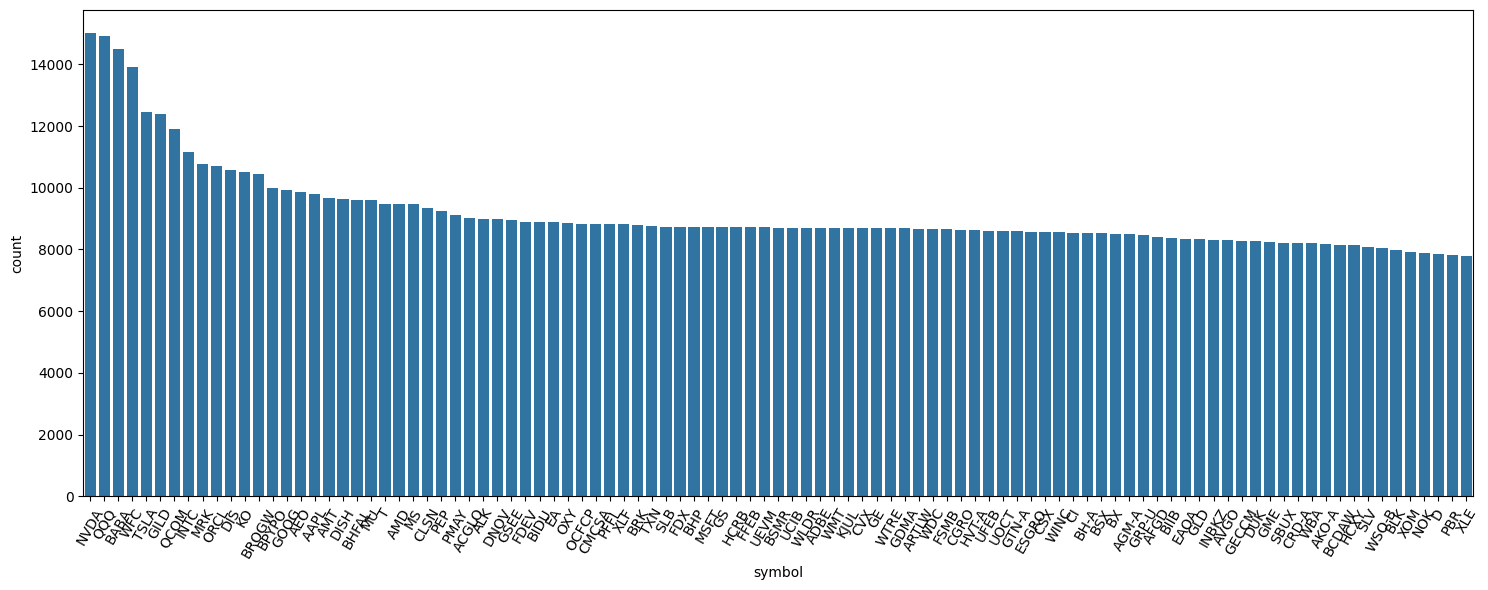

In [ ]:
plt.figure(figsize=(15, 6))

sns.barplot(data=symbol_count_df.head(100), x='symbol', y='count')  # Top 30 most frequent 
#sns.barplot(data=symbol_count_df, x='symbol', y='count')

plt.xticks(rotation=60)
plt.tight_layout()

In [ ]:
# less frequent symbols
symbol_count_df[symbol_count_df["count"]<100]


,symbol,count
806,PGHY,99
7995,MEA,99
621,OPWR,99
995,PTBI,99
4830,KOD,99
...,...,...
5834,TEAF,1
5788,SPSK,1
8493,SLMAP,1
8491,SGZA,1


In [ ]:
# with spark
# read the parquet file
# from pyspark.sql import SparkSession
# spark = SparkSession.builder \
#     .appName("FNSPID Streaming") \
#     .getOrCreate()
# df = spark.read.parquet(PARQUET_FILE)
# df.printSchema()
# df.show(5)  

## Working with filtered data
Since we have many missing values in some of the fields we will focus in non missing values only. We will only focus in specific columns that are useful for the future task. Thus, we drop all summary columns, as well as author and publisher.

### Nan proportion

In [2]:
df_chunk.columns

NameError: name 'df_chunk' is not defined

In [ ]:
df_chunk.drop(columns=["Publisher","Author",'Lsa_summary', 'Luhn_summary', 'Textrank_summary',
       'Lexrank_summary'], inplace=True)
# df_chunk.columns

In [6]:
# which articles do we have with all information
total_counts = 0
notna_counts = 0

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}")
    #same as before but we focus only in the important columns
    df_chunk = df_chunk.drop(columns=["Publisher","Author",'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary',
       #"Article",
       #"Stock_symbol"
       ], # exclude Article and symbol?
       ).drop_duplicates()
    total_counts += len(df_chunk)
    notna_counts += len(df_chunk.dropna())

ImportError: Missing optional dependency 'pyarrow'.  Use pip or conda to install pyarrow.

In [ ]:
# count dropping duplicates
total_counts

28585730

In [ ]:
notna_counts/total_counts

0.08716859775839203

In [ ]:
total_counts*(notna_counts/total_counts)

2491778.0

In [ ]:
df_chunk.columns

Index(['Date', 'Article_title', 'Stock_symbol', 'Url', 'Article'], dtype='object')

- Almost half of the dataset contain at least Date, Article and Url.
- 13% of the dataset contain the above and also stock symbol.
- 8% of the dataset contain all of the above and article body -> These are 2 Million records approx

### news count
How many news do we have from each stock if we only used the full rows?

In [3]:
# how many news do we have from each symbol
symbol_counter = Counter()

for chunk in os.listdir("chunks/news"):
    df_chunk = pd.read_feather(f"chunks/news/{chunk}").drop(columns=["Publisher","Author",'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']).dropna().drop_duplicates()
    symbol_counter.update(df_chunk['Stock_symbol'])
    print(f"added chunk {chunk}")

added chunk chunk_1.feather
added chunk chunk_10.feather
added chunk chunk_100.feather
added chunk chunk_101.feather
added chunk chunk_102.feather
added chunk chunk_103.feather
added chunk chunk_104.feather
added chunk chunk_105.feather
added chunk chunk_106.feather
added chunk chunk_107.feather
added chunk chunk_108.feather
added chunk chunk_109.feather
added chunk chunk_11.feather
added chunk chunk_110.feather
added chunk chunk_111.feather
added chunk chunk_112.feather
added chunk chunk_113.feather
added chunk chunk_114.feather
added chunk chunk_115.feather
added chunk chunk_116.feather
added chunk chunk_117.feather
added chunk chunk_118.feather
added chunk chunk_119.feather
added chunk chunk_12.feather
added chunk chunk_120.feather
added chunk chunk_121.feather
added chunk chunk_122.feather
added chunk chunk_123.feather
added chunk chunk_124.feather
added chunk chunk_125.feather
added chunk chunk_126.feather
added chunk chunk_127.feather
added chunk chunk_128.feather
added chunk chu

In [6]:
symbol_count_df = pd.DataFrame(symbol_counter.items(), columns=['symbol', 'count']).sort_values('count', ascending=False)
symbol_count_df

,symbol,count
653,BROGW,10456
638,BPYPO,9979
529,BHFAL,9614
3931,T,9449
3256,PMAY,9108
...,...,...
2012,GNRSW,1
637,BPYPN,1
3980,TECTP,1
3974,TEAF,1


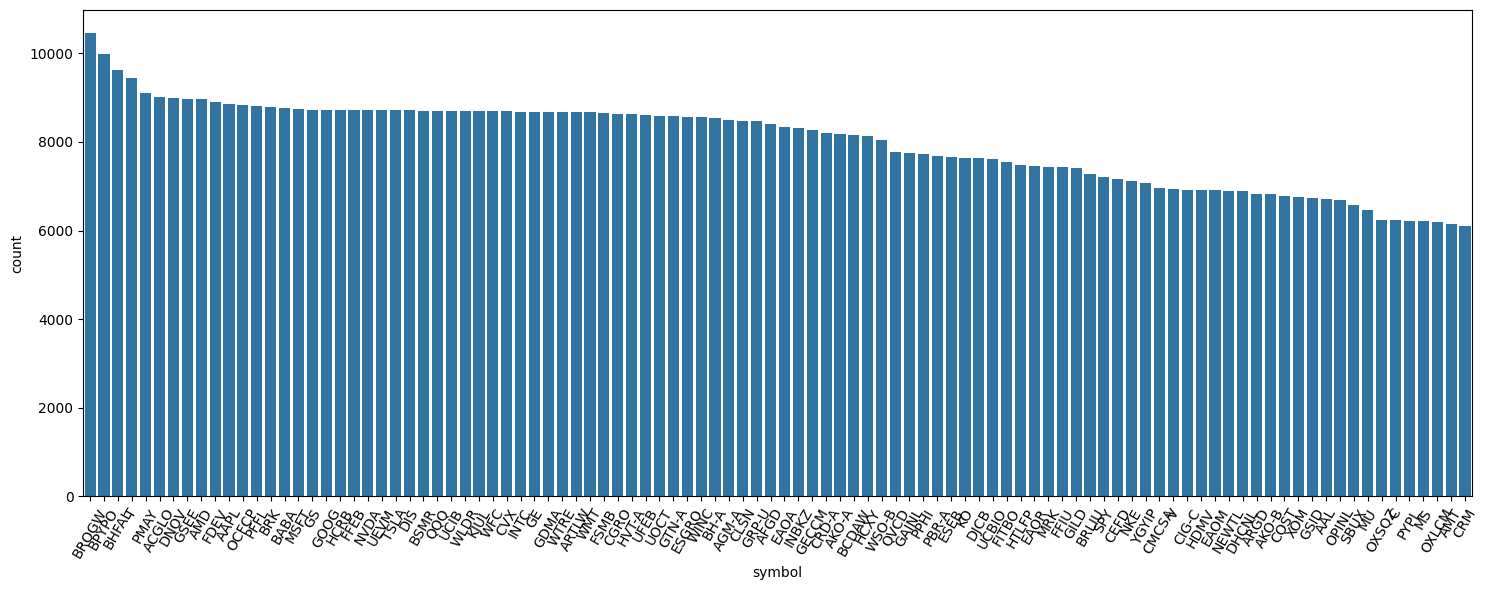

In [7]:
plt.figure(figsize=(15, 6))

sns.barplot(data=symbol_count_df.head(100), x='symbol', y='count')  # Top 30 most frequent 
#sns.barplot(data=symbol_count_df, x='symbol', y='count')

plt.xticks(rotation=60)
plt.tight_layout()

Checking the countries from SP100 and SP500

In [18]:
from pytickersymbols import PyTickerSymbols

pts = PyTickerSymbols()

sp500_list = pts.get_stocks_by_index("S&P 500")
sp500_list = [x["symbol"] for x in sp500_list]

print("sp500")
print(sp500_list)
print(len(sp500_list))

sp100_list = pts.get_stocks_by_index("S&P 100")
sp100_list = [x["symbol"] for x in sp100_list]

print("sp100")
print(sp100_list)
print(len(sp100_list))

sp500
['LIN', 'CCL', 'SSE', 'MMM', 'AXP', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DOW', 'XOM', 'GS', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'NKE', 'MRK', 'MSFT', 'PFE', 'PG', 'TRV', 'UNH', 'VZ', 'V', 'WMT', 'WBA', 'DIS', 'ATVI', 'ADBE', 'AKAM', 'GOOGL', 'AMZN', 'AAL', 'AMGN', 'ADI', 'AMAT', 'ADSK', 'ADP', 'BIIB', 'CHTR', 'CTSH', 'CMCSA', 'COST', 'CSX', 'XRAY', 'DISH', 'DLTR', 'EBAY', 'EA', 'EXPE', 'FAST', 'FISV', 'GILD', 'HSIC', 'ILMN', 'INCY', 'INTU', 'ISRG', 'KHC', 'LRCX', 'MAR', 'MCHP', 'MU', 'MDLZ', 'MNST', 'NTAP', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'PCAR', 'PAYX', 'PYPL', 'QCOM', 'REGN', 'ROST', 'STX', 'SWKS', 'SBUX', 'TMUS', 'TSLA', 'TXN', 'TSCO', 'ULTA', 'VRSK', 'VRTX', 'WDC', 'ABT', 'ABBV', 'ACN', 'ALL', 'MO', 'AIG', 'T', 'BAC', 'BK', 'BRK-B', 'BLK', 'BKNG', 'BMY', 'COF', 'C', 'CL', 'COP', 'CVS', 'DHR', 'DUK', 'LLY', 'EMR', 'EXC', 'FDX', 'F', 'GE', 'GM', 'HON', 'KMI', 'LOW', 'MA', 'MDT', 'MET', 'MS', 'NEE', 'OXY', 'ORCL', 'PM', 'RTN', 'SLB', 'SPG', 'SO', 'TGT', 'UNP', 'UPS',

In [ ]:
symbol_count_df_sp100 = symbol_count_df[symbol_count_df["symbol"].isin(sp100_list)]
symbol_count_df_sp100#[symbol_count_df_sp100["count"] > 1000]

The reduced dataset would contain 74 companies from the SP100 or 65 if we only include the companies with more than 1000 news.

In [14]:
symbol_count_df_sp500 = symbol_count_df[symbol_count_df["symbol"].isin(sp500_list)]
symbol_count_df_sp500#[symbol_count_df_sp500["count"] > 1000]

,symbol,count
3931,T,9449
222,AMD,8959
12,AAPL,8865
2704,MSFT,8737
2052,GS,8730
...,...,...
274,AOS,7
171,AJG,7
2412,L,7
2306,K,7


In [9]:
symbol_count_df_sp500[symbol_count_df_sp500["count"] > 1000]["count"].sum() # number of useful news with this news set

np.int64(659013)

In [10]:
symbol_count_df_sp100[symbol_count_df_sp100["count"] > 1000].symbol.to_csv("tickers_sp100.csv",index=None)
symbol_count_df_sp500[symbol_count_df_sp500["count"] > 1000].symbol.to_csv("tickers_sp500.csv",index=None)

And 370 companies from the SP500.

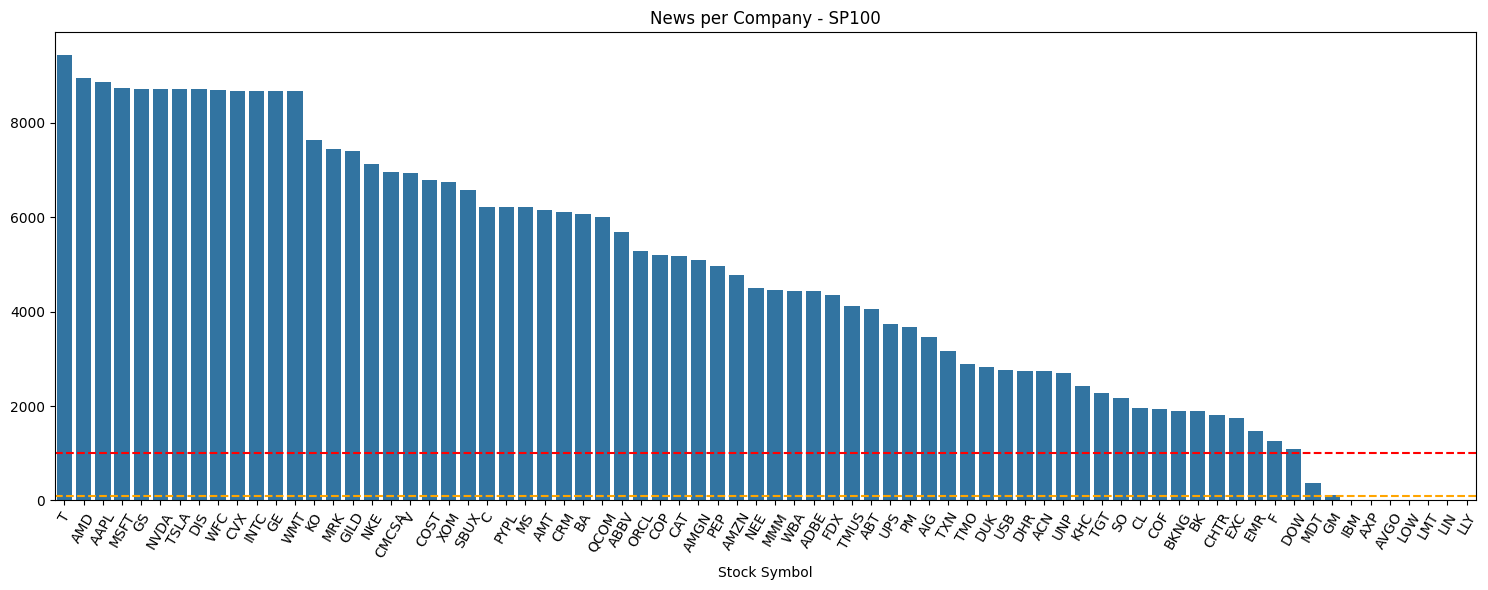

In [56]:
plt.figure(figsize=(15, 6))
plt.title("News per Company - SP100")
sns.barplot(data=symbol_count_df_sp100, x='symbol', y='count')

plt.axhline(y=1000, color='red', linestyle='--', label='Threshold 1000')
plt.axhline(y=100, color='orange', linestyle='--', label='Threshold 100')

plt.xlabel("Stock Symbol")
plt.ylabel("")
plt.xticks(rotation=60)
plt.tight_layout()

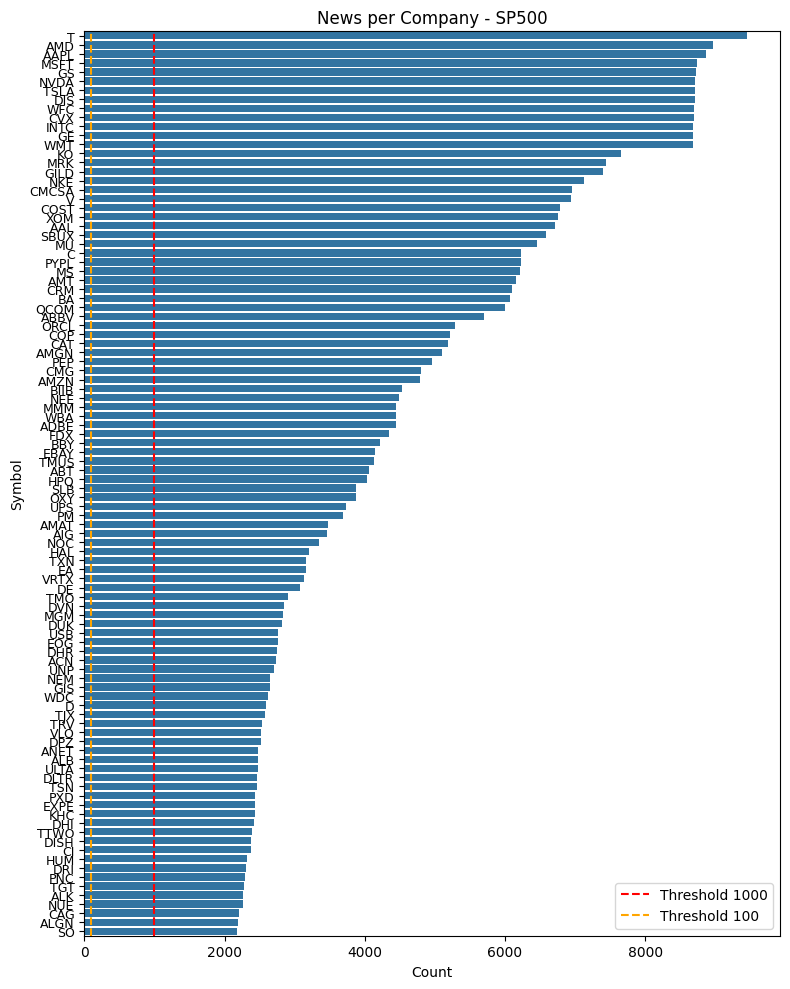

In [16]:
plt.figure(figsize=(8, 10))
plt.title("News per Company - SP500")

sns.barplot(data=symbol_count_df_sp500.head(100), y='symbol', x='count', orient="h")
plt.yticks(fontsize=9)
plt.axvline(x=1000, color='red', linestyle='--', label='Threshold 1000')
plt.axvline(x=100, color='orange', linestyle='--', label='Threshold 100')
plt.xlabel('Count')
plt.ylabel('Symbol')
plt.tight_layout()
plt.legend()

#### Exploring Sp 400 and sp 600

In [19]:
# now companies from the sp1000
import pandas as pd

url_mid = "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies"
url_small = "https://en.wikipedia.org/wiki/List_of_S%26P_600_companies"

df_mid = pd.read_html(url_mid, header=0)[0] # sp 400
df_small = pd.read_html(url_small, header=0)[0] # sp 600

df_mid

# CODE FOR SP1000
# Concatenate tickers from both indices to create sp1000
# tickers_mid = df_mid['Symbol'].tolist()
# tickers_small = df_small['Symbol'].tolist()
# sp1000_list = tickers_mid + tickers_small

# sp1000_list = list(set([ticker.replace('.', '-') for ticker in sp1000_list]))

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,SEC filings
0,AA,Alcoa,Materials,Aluminum,"Pittsburgh, Pennsylvania",reports
1,AAL,American Airlines Group,Industrials,Passenger Airlines,"Fort Worth, Texas",reports
2,AAON,AAON,Industrials,Building Products,"Tulsa, Oklahoma",reports
3,ACHC,Acadia Healthcare,Health Care,Health Care Facilities,"Franklin, Tennessee",reports
4,ACI,Albertsons,Consumer Staples,Food Retail,"Boise, Idaho",reports
...,...,...,...,...,...,...
396,WWD,"Woodward, Inc.",Industrials,Electrical Components & Equipment,"Fort Collins, Colorado",reports
397,XPO,"XPO, Inc.",Industrials,Cargo Ground Transportation,"Greenwich, Connecticut",reports
398,XRAY,Dentsply Sirona,Health Care,Health Care Supplies,"Charlotte, North Carolina",reports
399,YETI,Yeti Holdings,Consumer Discretionary,Leisure Products,"Austin, Texas",reports


In [20]:
sp400_list = df_mid["Symbol"].tolist()
sp600_list = df_small["Symbol"].tolist()

In [ ]:
symbol_count_df_sp400 =  symbol_count_df[symbol_count_df["symbol"].isin(sp400_list)]
symbol_count_df_sp600 =  symbol_count_df[symbol_count_df["symbol"].isin(sp600_list)]

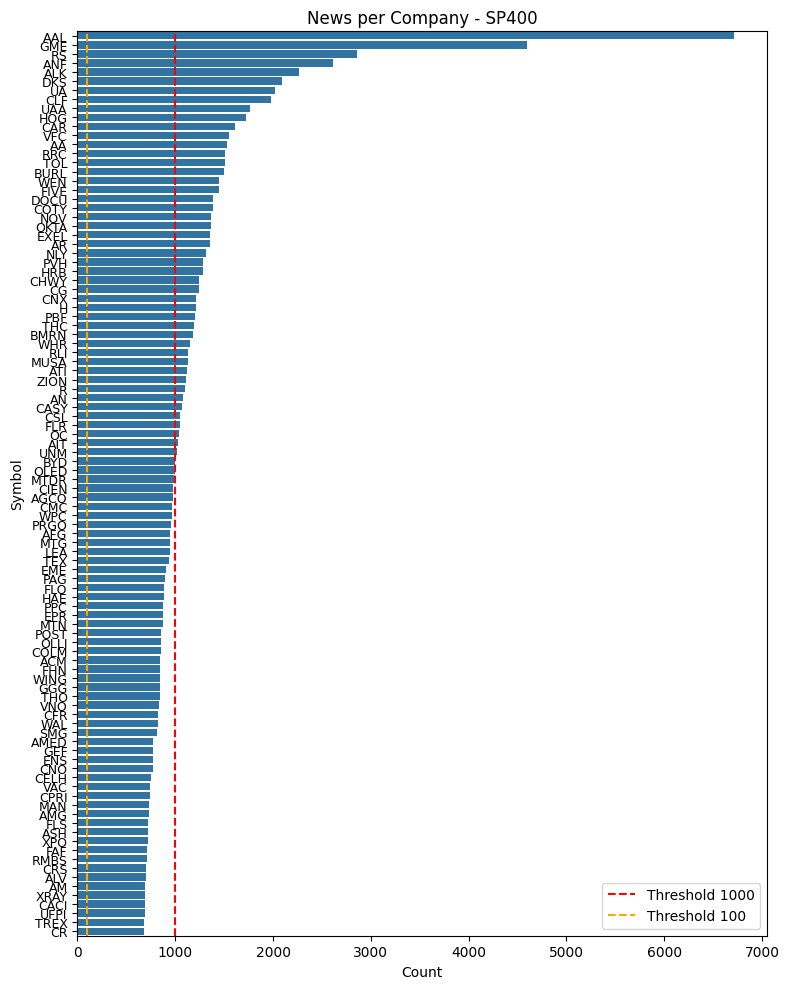

In [25]:
# visualization
plt.figure(figsize=(8, 10))
plt.title("News per Company - SP400")

sns.barplot(data=symbol_count_df_sp400.head(100), y='symbol', x='count', orient="h")
plt.yticks(fontsize=9)
plt.axvline(x=1000, color='red', linestyle='--', label='Threshold 1000')
plt.axvline(x=100, color='orange', linestyle='--', label='Threshold 100')
plt.xlabel('Count')
plt.ylabel('Symbol')
plt.tight_layout()
plt.legend()

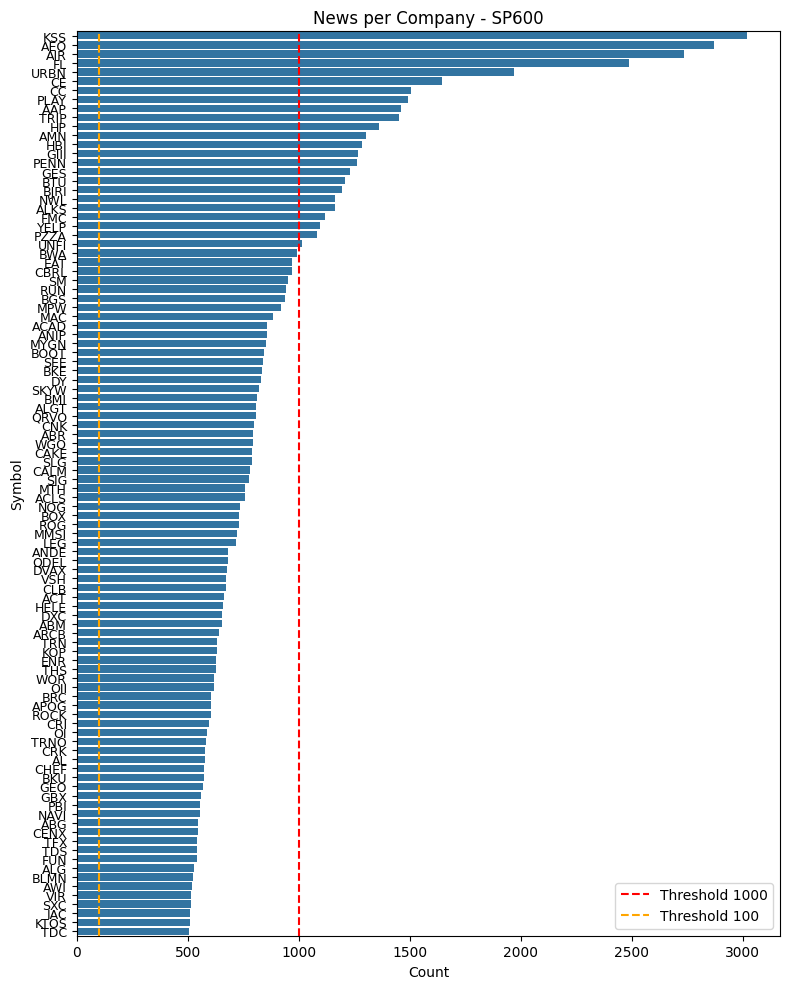

In [26]:
plt.figure(figsize=(8, 10))
plt.title("News per Company - SP600")

sns.barplot(data=symbol_count_df_sp600.head(100), y='symbol', x='count', orient="h")
plt.yticks(fontsize=9)
plt.axvline(x=1000, color='red', linestyle='--', label='Threshold 1000')
plt.axvline(x=100, color='orange', linestyle='--', label='Threshold 100')
plt.xlabel('Count')
plt.ylabel('Symbol')
plt.tight_layout()
plt.legend()

The counts are okay, AAL is American Airlines Gorup and AAPL is Apple.

##### Checking for duplicated news (Correction on news total count)
There may be some news that speak about different companies, so the actual number of news should not be computed as the sum of the total records. Instead we should remove duplicates.

In [ ]:
df_chunk = next(pd.read_csv("filtered_news.csv", chunksize=100000))

In [ ]:
df_chunk.sort_values(by="Article_title", inplace=True)
df_chunk

,Date,Article_title,Stock_symbol,Url,Article
6147,2020-03-25 00:00:00 UTC,"""Airlines"" Didn't Waste All Their Cash Flow on...",AAL,https://www.nasdaq.com/articles/airlines-didnt...,"Last Monday, Bloomberg reported that the top f..."
14492,2023-08-04 00:00:00 UTC,"""Big Tech"" Earnings Review: ETFs in Focus",AAPL,https://www.nasdaq.com/articles/big-tech-earni...,"Since late July, five major tech companies fro..."
22206,2023-09-13 00:00:00 UTC,"""Blockbuster Status"": 3 Bios to Buy and Hold",ABBV,https://www.nasdaq.com/articles/blockbuster-st...,Profitability in the Biotech Industry is Hard ...
7224,2018-01-04 00:00:00 UTC,"""Culture"" Has a High Cost at American Airlines",AAL,https://www.nasdaq.com/articles/culture-has-hi...,"For the past year or so, American Airlines ' (..."
45399,2023-12-11 00:00:00 UTC,"""Grand Theft Auto 6"" Won't Launch Till 2025. I...",ACGLO,https://www.nasdaq.com/articles/grand-theft-au...,"Its sales growth has been meager in 2023, and ..."
...,...,...,...,...,...
99862,2023-12-16 00:00:00 UTC,‘We Are Bullish on Cybersecurity’: Susquehanna...,AGM-A,https://www.nasdaq.com/articles/we-are-bullish...,New technologies bring with them new demands o...
41520,2023-12-16 15:00:00 UTC,‘We Are Bullish on Cybersecurity’: Susquehanna...,ACGLO,https://www.nasdaq.com/articles/we-are-bullish...,New technologies bring with them new demands o...
85866,2023-12-16 00:00:00 UTC,‘We Are Bullish on Cybersecurity’: Susquehanna...,AFGD,https://www.nasdaq.com/articles/we-are-bullish...,New technologies bring with them new demands o...
37857,2019-12-04 00:00:00 UTC,“Cannabis 2.0” Can Be a Game Changer for These...,ACB,https://www.nasdaq.com/articles/cannabis-2.0-c...,There has been a lot of hype concerning what h...


Yes there are duplicates!

In [39]:
df_chunk.groupby("Article_title").agg({"Stock_symbol":lambda x: x.tolist()})

,Stock_symbol
Article_title,
"""Airlines"" Didn't Waste All Their Cash Flow on Share Buybacks: American Airlines Did",[AAL]
"""Big Tech"" Earnings Review: ETFs in Focus",[AAPL]
"""Blockbuster Status"": 3 Bios to Buy and Hold",[ABBV]
"""Culture"" Has a High Cost at American Airlines",[AAL]
"""Grand Theft Auto 6"" Won't Launch Till 2025. Is Take-Two Stock Still a Buy?","[ACGLO, AFGD]"
...,...
"‘Time to Upgrade,’ Says J.P. Morgan About These 2 Energy Stocks","[ACGLO, AFGD]"
‘Too Cheap to Ignore’: Cathie Wood Snaps Up These 2 Stocks Under $10,[ADPT]
‘We Are Bullish on Cybersecurity’: Susquehanna Recommends 3 Stocks to Consider,"[AGM-A, ACGLO, AFGD]"


We first filter the news that contain companies from the SP500, 400 or 600 and we store them in another dataset.

In [21]:
target_symbols = set(sp500_list+sp400_list+sp600_list)
print(len(target_symbols))
target_symbols

1475


{'SGH',
 'ROK',
 'SGI',
 'LOW',
 'RF',
 'TMO',
 'MGY',
 'MPC',
 'CDAY',
 'AGCO',
 'BC',
 'H',
 'ECG',
 'THRY',
 'JCI',
 'FDS',
 'PNC',
 'SFM',
 'PG',
 'CF',
 'MS',
 'TRGP',
 'KD',
 'CAVA',
 'VVV',
 'NXT',
 'KLG',
 'CVBF',
 'PRGO',
 'ALRM',
 'TPR',
 'AMCR',
 'UNFI',
 'CAR',
 'GXO',
 'SLP',
 'POWI',
 'UNH',
 'CNC',
 'MCY',
 'HES',
 'WKC',
 'MANH',
 'MDLZ',
 'RSG',
 'ADC',
 'BHE',
 'RWT',
 'ICHR',
 'GMS',
 'ORA',
 'PARR',
 'SKX',
 'DLX',
 'GRBK',
 'CWEN',
 'CPT',
 'BDN',
 'REXR',
 'SDGR',
 'TMUS',
 'IRDM',
 'JPM',
 'MOG.A',
 'AUB',
 'GNL',
 'KOP',
 'RHI',
 'RMBS',
 'RTN',
 'ELS',
 'MATX',
 'OPCH',
 'UPS',
 'PCAR',
 'TMHC',
 'EMN',
 'CPB',
 'HMN',
 'DIOD',
 'POWL',
 'DPZ',
 'GPI',
 'FCFS',
 'CWEN.A',
 'CE',
 'BHLB',
 'RPM',
 'TFX',
 'PBF',
 'ALG',
 'OI',
 'ZBH',
 'PXD',
 'TGNA',
 'WTFC',
 'SONO',
 'AZO',
 'COF',
 'ELF',
 'AVAV',
 'VTLE',
 'WS',
 'EVTC',
 'ABC',
 'HCI',
 'COHR',
 'MOH',
 'JEF',
 'ON',
 'PEG',
 'FDP',
 'PI',
 'OXY',
 'TNL',
 'ABM',
 'NEO',
 'POOL',
 'OMI',
 'WOR',
 'CHRW',
 

In [ ]:
output_csv = "filtered_news_only_SP.csv"
input_csv = "filtered_news.csv"

for chunk in pd.read_csv(input_csv, chunksize=100000):
    chunk = chunk[chunk["Stock_symbol"].isin(target_symbols)]
    print(f"Remaining news after filtering:{len(chunk)}")
    chunk.to_csv(
        output_csv,
        mode='a',
        index=False,
        header=not os.path.exists(output_csv)  # header if file is newly created
    )

Remaining news after filtering:63582
Remaining news after filtering:55698
Remaining news after filtering:43420
Remaining news after filtering:27944
Remaining news after filtering:40975
Remaining news after filtering:48803
Remaining news after filtering:58772
Remaining news after filtering:41353
Remaining news after filtering:42556
Remaining news after filtering:31330
Remaining news after filtering:25584
Remaining news after filtering:45459
Remaining news after filtering:34030
Remaining news after filtering:36022
Remaining news after filtering:62706
Remaining news after filtering:55207
Remaining news after filtering:38843
Remaining news after filtering:39605
Remaining news after filtering:40411
Remaining news after filtering:46984
Remaining news after filtering:37761
Remaining news after filtering:46044
Remaining news after filtering:39982
Remaining news after filtering:45273
Remaining news after filtering:19858


We observed that some news articles are duplicated in the dataset. For example, if a single news article mentions three different companies, it will appear as three separate records with identical text and properties, except for the company field. Since our analysis focuses on the news content itself, we want to avoid processing duplicate articles. To address this, we apply an additional filter to remove duplicate news articles. You may need to run this filtering step multiple times to ensure all duplicates are removed.

In [15]:
# output_csv = "filtered_news_only_SP_no_duplicates_v8.csv"
input_csv = "filtered_news_only_SP_no_duplicates_v8.csv"


# use this input only the first time
# input_csv = "filtered_news_only_SP.csv"

for chunk in pd.read_csv(input_csv, chunksize=700000):
    
    chunk.sort_values(by="Article_title", inplace=True) # sort in alphabetical order
    chunk = chunk.drop_duplicates(subset=["Article_title"]) 
    
    print(f"Remaining news after filtering:{len(chunk)}")

    # chunk.to_csv(
    #     output_csv,
    #     mode='a',
    #     index=False,
    #     header=not os.path.exists(output_csv)  # header if file is newly created
    # )

Remaining news after filtering:662391


In [14]:
chunk.head()

,Date,Article_title,Stock_symbol,Url,Article
0,2012-12-18 00:00:00 UTC,"""$2-Billion Man"" Prem Watsa Revisited, Plus Hi...",USB,https://www.nasdaq.com/articles/2-billion-man-...,"For a man who once said, ""You have to turn you..."
1,2021-10-19 00:00:00 UTC,"""9 Foolish Truths That I Hold to Be Self-Evident""",NVDA,https://www.nasdaq.com/articles/9-foolish-trut...,"If you're a longtime listener to this podcast,..."
2,2020-03-25 00:00:00 UTC,"""Airlines"" Didn't Waste All Their Cash Flow on...",AAL,https://www.nasdaq.com/articles/airlines-didnt...,"Last Monday, Bloomberg reported that the top f..."
3,2018-09-22 00:00:00 UTC,"""Alexa, Make Me Money"": Conversational AI Prep...",ORCL,https://www.nasdaq.com/articles/alexa-make-me-...,We've already gotten comfortable with digital ...
4,2013-12-10 00:00:00 UTC,"""Anonymous"" Pleads Guilty in PayPal Case - Ana...",EBAY,https://www.nasdaq.com/articles/anonymous-plea...,"As per the U.S. Department of Justice, 13 memb..."


After removing duplicated news and companies outside from the SP indexes there are 662,000 different news.

##### code for sp1000

In [21]:
# symbol_count_df_sp1000 = symbol_count_df[symbol_count_df["symbol"].isin(sp1000_list)]
# symbol_count_df_sp1000[symbol_count_df_sp1000["count"] > 100]

Only 72 of the companies appear in the news dataset with 1000 threshold?? 

We can just focus on the SP500 then, which to the best of our knowledge is one of the biggest indexes that contains a wide variety of companies of different sectors

In [47]:
symbol_count_df_sp1000[symbol_count_df_sp1000["count"] > 1000]["count"].sum() # number of useful news with this news set

np.int64(113809)

In [48]:
# con un corte menos estricto
symbol_count_df_sp1000[symbol_count_df_sp1000["count"] > 100]["count"].sum() # number of useful news with this news set

np.int64(359384)

In [20]:
symbol_count_df_sp1000["count"].sum() # number of useful news with this news set

np.int64(360822)

In [21]:
symbol_count_df_sp500["count"].sum() # number of useful news with this news set

np.int64(731387)

Si usamos el set del SP500 ademas tenemos el doble de noticias disponibles para enlazar con lso eventos. Que preferimos tener un set mas grande de empresas pero menos noticias y datos sobre eventos disponibles o un set mas pequeno de empresas pero muchas mas noticias disponibles para enlazar con los eventos? Yo personalmente creo que lo segundo, si no creo que hay peligro de que los reports esten muy sesgados hcia las empresas que tienen mas noticias asociadas.

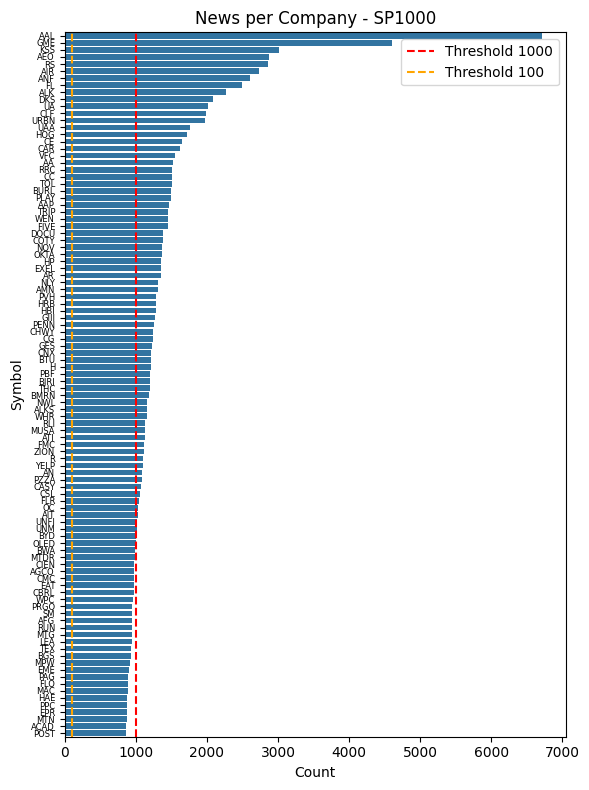

In [18]:
plt.figure(figsize=(6, 8))
plt.title("News per Company - SP1000")

sns.barplot(data=symbol_count_df_sp1000.head(100), y='symbol', x='count', orient="h")
plt.yticks(fontsize=6)
plt.xlabel('Count')
plt.ylabel('Symbol')
plt.axvline(x=1000, color='red', linestyle='--', label='Threshold 1000')
plt.axvline(x=100, color='orange', linestyle='--', label='Threshold 100')

plt.legend()
plt.tight_layout()

Cuando comparamos las graficas creo que la de SP500 esta mas equilibrada, en general no hay una empresa que tenga muchas mas noticias que el resto, esta mas parejo. Tambien hay mas noticias que hablan sobre las empresas del SP500 en general.

#### Save the the company lists to csv

In [27]:
symbol_count_df_sp400.symbol.to_csv("tickers_sp400_all.csv",index=None)
symbol_count_df_sp500.symbol.to_csv("tickers_sp500_all.csv",index=None)
symbol_count_df_sp600.symbol.to_csv("tickers_sp600_all.csv",index=None)

In [24]:
pd.Series(sorted(target_symbols)).to_csv("tickers_FinKG.csv", index=False, header=False)

### Getting the token counts

In [ ]:
bin_edges = np.linspace(0, 50000, 1000)
hist = np.zeros(len(bin_edges) - 1)

for chunk in os.listdir("chunks/news"): 
      
    df_chunk = pd.read_feather(
        f"chunks/news/{chunk}",
        columns=["Article"]).dropna(subset=["Article"])

    df_chunk["tokens"] = df_chunk["Article"].str.count(r"\S+")
    values = df_chunk["tokens"].to_numpy()
    if values.size > 0:
        print(f"reading {chunk}: max length {values.max()}") 

    h, _ = np.histogram(values, bins=bin_edges)
    hist += h

hist

reading chunk_127.feather: max length 13392
reading chunk_128.feather: max length 11339
reading chunk_129.feather: max length 11236
reading chunk_130.feather: max length 10997
reading chunk_131.feather: max length 41140
reading chunk_132.feather: max length 52590
reading chunk_133.feather: max length 41140
reading chunk_134.feather: max length 41140
reading chunk_135.feather: max length 55322
reading chunk_136.feather: max length 41140
reading chunk_137.feather: max length 41140
reading chunk_138.feather: max length 24111
reading chunk_139.feather: max length 22207
reading chunk_140.feather: max length 24351
reading chunk_141.feather: max length 41140
reading chunk_142.feather: max length 41140
reading chunk_143.feather: max length 39243
reading chunk_144.feather: max length 41140
reading chunk_145.feather: max length 41140
reading chunk_146.feather: max length 41140
reading chunk_147.feather: max length 41143
reading chunk_148.feather: max length 41140
reading chunk_149.feather: max l

array([8.23740e+04, 2.39188e+05, 5.89573e+05, 6.55507e+05, 4.69827e+05,
       3.21485e+05, 3.17241e+05, 2.23363e+05, 1.89593e+05, 1.51414e+05,
       1.32406e+05, 1.34951e+05, 1.30807e+05, 1.39011e+05, 1.51955e+05,
       1.52980e+05, 1.39100e+05, 1.17011e+05, 1.00898e+05, 8.83290e+04,
       7.57560e+04, 6.10750e+04, 5.05780e+04, 4.06210e+04, 3.01250e+04,
       2.26110e+04, 1.83960e+04, 1.55800e+04, 1.27070e+04, 1.15070e+04,
       1.30730e+04, 1.01900e+04, 8.62300e+03, 8.07900e+03, 6.06700e+03,
       4.65400e+03, 4.17700e+03, 3.57600e+03, 3.11000e+03, 3.12600e+03,
       2.27600e+03, 1.84300e+03, 1.53300e+03, 1.38500e+03, 1.22700e+03,
       1.26100e+03, 9.87000e+02, 9.38000e+02, 8.34000e+02, 7.86000e+02,
       8.38000e+02, 7.91000e+02, 7.48000e+02, 6.18000e+02, 6.18000e+02,
       6.66000e+02, 5.78000e+02, 7.03000e+02, 5.30000e+02, 5.92000e+02,
       5.23000e+02, 4.69000e+02, 6.41000e+02, 4.29000e+02, 4.25000e+02,
       3.50000e+02, 3.87000e+02, 4.01000e+02, 3.83000e+02, 3.040

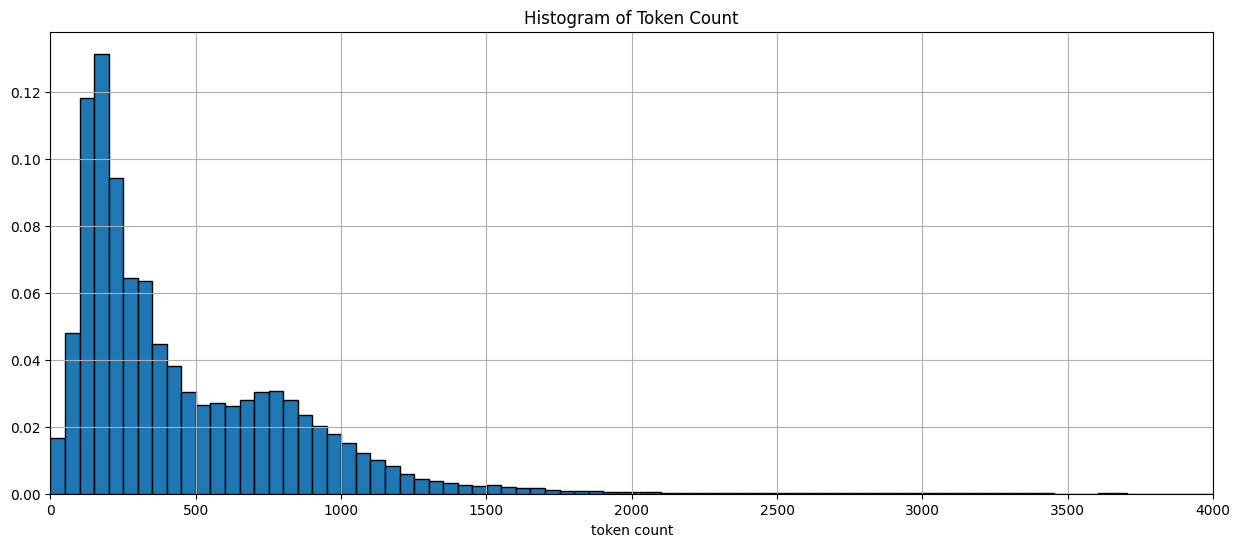

In [ ]:

plt.figure(figsize=(15, 6))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', edgecolor='black')
plt.xlim((0,4000))
plt.xlabel("token count")
plt.title("Histogram of Token Count")
plt.grid(True)
plt.show()


(0.0, 6000.0)

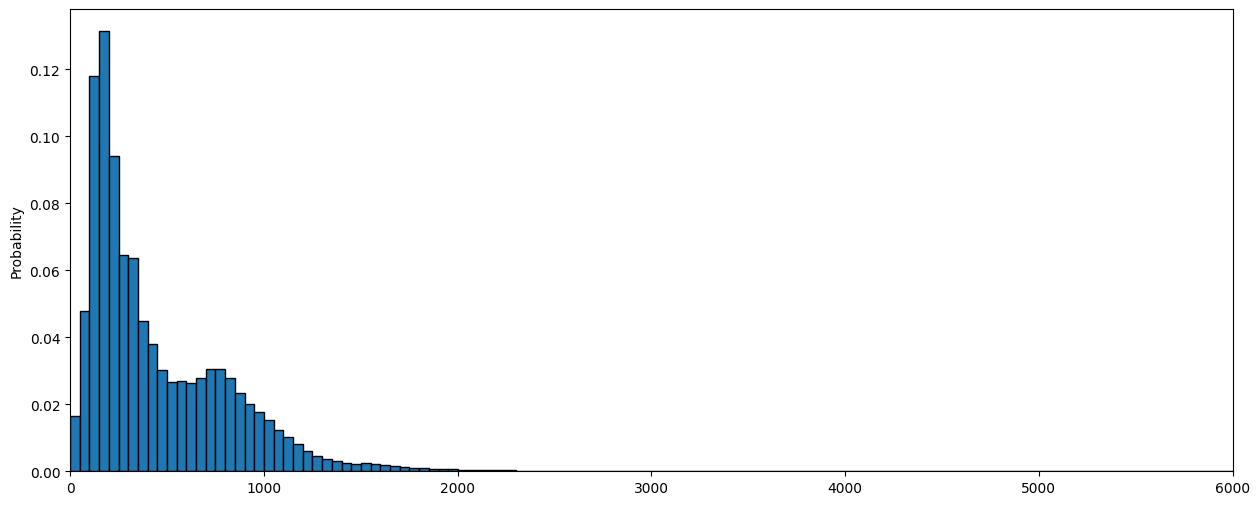

In [ ]:
hist = hist / hist.sum()  # Normalize to get proba
plt.figure(figsize=(15, 6))

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', edgecolor='black')
plt.ylabel("Probability")
plt.xlim((0,6000))


## Checking news dates range


In [ ]:
date_min, date_max = None, None
for chunk in pd.read_csv("filtered_news.csv", usecols=["Date"], chunksize=100_000):
    chunk_dates = pd.to_datetime(chunk["Date"], errors="coerce")
    chunk_min = chunk_dates.min()
    chunk_max = chunk_dates.max()
    if date_min is None or (chunk_min is not pd.NaT and chunk_min < date_min):
        date_min = chunk_min
    if date_max is None or (chunk_max is not pd.NaT and chunk_max > date_max):
        date_max = chunk_max

print(f"Date range: {date_min} to {date_max}")

Date range: 2009-04-08 00:00:00+00:00 to 2024-01-09 00:00:00+00:00
